In [2]:
from sklearn.cluster import KMeans
# from cuml import KMeans as cumlKMeans
from blazingsql import BlazingContext
import matplotlib.pyplot as plt
import seaborn as sns
import cudf
import time

bc_cudf = BlazingContext()

BlazingContext ready


In [3]:
netflow_gdf_cudf = cudf.read_csv('./data/sample.csv')
bc_cudf.create_table('netflow', netflow_gdf_cudf)

/usr/local/envs/bsql/lib/python3.7/site-packages/fsspec/implementations/local.py:33: FutureWarning: The default value of auto_mkdir=True has been deprecated and will be changed to auto_mkdir=False by default in a future release.
  FutureWarning,


In [4]:
query = '''
        SELECT
            a.firstSeenSrcTotalBytes as bytesOut,
            a.firstSeenDestTotalBytes as bytesIn
        FROM
            netflow a
        '''

%prun result = bc_cudf.sql(query)

         1713 function calls (1712 primitive calls) in 0.644 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.628    0.628    0.628    0.628 context.py:906(explain)
        1    0.013    0.013    0.015    0.015 {built-in method cio.runQueryCaller}
        1    0.001    0.001    0.001    0.001 {built-in method cio.getTableScanInfoCaller}
       64    0.000    0.000    0.001    0.000 dtypes.py:79(is_categorical_dtype)
      210    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:1009(_handle_fromlist)
      550    0.000    0.000    0.000    0.000 {built-in method builtins.hasattr}
      679    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
        1    0.000    0.000    0.644    0.644 {built-in method builtins.exec}
        1    0.000    0.000    0.644    0.644 context.py:1374(sql)
       66    0.000    0.000    0.000    0.000 common.py:2020(pandas_dtype)
       22    0.000 

In [ ]:
!conda install -c rapidsai -c nvidia -c conda-forge -c defaults rapids=0.14 python=3.7

In [10]:
cuml_times=[]
result_float = result.astype(cudf.float32)
data_points = result.values
print(data_points)

for i in range(3, 5):
    t0 = time.time()
    kmeans = cumlKMeans(n_clusters=3).fit(data_points)
    t1 = time.time()
    times.append(t1-t0)

    result['cluster_id'] = kmeans.labels_
    sns.lmplot('bytesOut', 'bytesIn', data=result, fit_reg=False,
               scatter_kws={"s":150}, hue="cluster_id")

    plt.title('kmean plot %d', i)
    plt.show()

AttributeError: module 'cudf' has no attribute 'float32'

         bytesOut  bytesIn
0             422      403
1             186        0
2             243        0
3             448      506
4            5730    84250
...           ...      ...
4999995       297      619
4999996       297      619
4999997       297      619
4999998       297      619
4999999       297      619

[5000000 rows x 2 columns]
[[422 403]
 [186   0]
 [243   0]
 ...
 [297 619]
 [297 619]
 [297 619]]
 

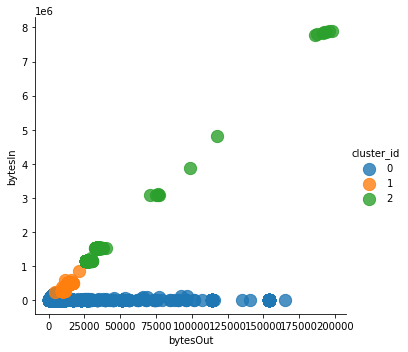

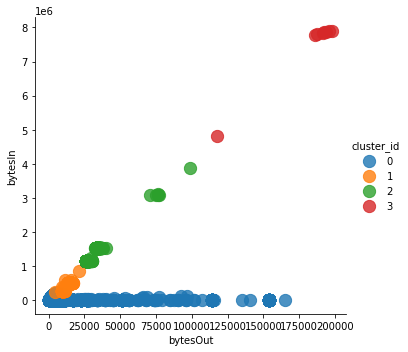

         18530 function calls (18101 primitive calls) in 14.554 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       73    3.391    0.046    5.284    0.072 pairwise.py:200(euclidean_distances)
       33    3.278    0.099    3.281    0.099 _k_means_elkan.pyx:183(__pyx_fuse_1elkan_iter_chunked_dense)
       73    1.538    0.021    1.538    0.021 extmath.py:119(safe_sparse_dot)
        1    1.455    1.455   14.553   14.553 _kmeans.py:939(fit)
       10    1.338    0.134    1.338    0.134 _k_means_elkan.pyx:32(__pyx_fuse_1init_bounds_dense)
      302    1.130    0.004    1.130    0.004 {method 'reduce' of 'numpy.ufunc' objects}
       10    0.939    0.094    7.570    0.757 _kmeans.py:47(_k_init)
       30    0.772    0.026    0.772    0.026 {method 'cumsum' of 'numpy.ndarray' objects}
       10    0.345    0.035    0.345    0.035 _k_means_fast.pyx:99(__pyx_fuse_1_inertia_dense)
  741/571    0.134    0.000    1.636    0.003 {b

In [12]:
times=[]
pd = result.to_pandas()
print(pd)
data_points = pd.values
print(data_points)

for i in range(3, 5):
    t0 = time.time()
    %prun kmeans = KMeans(n_clusters=i).fit(data_points)
    t1 = time.time()
    times.append(t1-t0)

    pd['cluster_id'] = kmeans.labels_
    sns.lmplot('bytesOut', 'bytesIn', data=pd, fit_reg=False,
               scatter_kws={"s":150}, hue="cluster_id")

#    plt.title('kmean plot %d', i)
    plt.show()

In [13]:
print(times)

[11.65560269355774, 14.562059879302979]


In [ ]:
result_pd = result.to_pandas()

times_pd=[]

for i in range(3, 5):
    t0 = time.time()
    %prun kmeans = KMeans(n_clusters=i,algorithm='auto').fit(result_pd)
    t1 = time.time()
    times_pd.append(t1-t0)

    result_pd['cluster_id'] = kmeans.labels_
    sns.lmplot('bytesOut', 'bytesIn', data=result, fit_reg=False,
               scatter_kws={"s":150}, hue="cluster_id")

    plt.title('kmean plot' + i)
    plt.show()

In [ ]:
print(times_pd)